# EDA

Phần EDA này dùng để hiểu dữ liệu California Housing trước khi bước sang Preprocessing và Feature Engineering

Cách thực hiện gồm kết hợp bảng thống kê và biểu đồ trực quan. Với biến số, notebook sẽ xem xét thống kê mô tả, độ lệch phân phối, histogram, boxplot và outlier theo IQR. Với biến phân loại, notebook sẽ trực quan hóa tần suất xuất hiện và tập trung vào các nhóm phổ biến để tránh biểu đồ quá rối. Cuối cùng, notebook sẽ phân tích tương quan, quan hệ giữa target với các đặc trưng quan trọng, và vẽ bản đồ scatter theo `Longitude`, `Latitude` để quan sát phân bố giá nhà theo không gian địa lý.

### Data Overview

#### Load Dataset


In [17]:
from pathlib import Path
import os
import warnings

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11
warnings.filterwarnings("ignore")

candidate_paths = [
    Path("data/raw/California_Housing_CitiesAdded.csv"),
    Path("practice_4/data/raw/California_Housing_CitiesAdded.csv"),
]

DATA_PATH = next((candidate for candidate in candidate_paths if candidate.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Không tìm thấy file California_Housing_CitiesAdded.csv")

df = pd.read_csv(DATA_PATH)
df.head()

,Median_House_Value,Median_Income,Median_Age,Tot_Rooms,Tot_Bedrooms,Population,Households,Latitude,Longitude,Distance_to_coast,Distance_to_LA,Distance_to_SanDiego,Distance_to_SanJose,Distance_to_SanFrancisco,ocean_proximity,City
0,500001.0,1.2434,52,249,78,396,85,37.80,-122.27,2524.614616,552234.0515,731023.5749,61415.35211,14466.70538,NEAR BAY,Alameda
1,500001.0,1.1696,52,609,236,1349,250,37.87,-122.25,7897.024567,556856.9280,735788.3723,67242.51828,19172.81885,NEAR BAY,Alameda
2,500001.0,7.8521,52,1668,225,517,214,37.86,-122.24,9154.528309,555442.5086,734372.6023,65849.13943,19335.74118,NEAR BAY,Alameda
3,500001.0,9.3959,52,3726,474,1366,496,37.85,-122.24,8259.085109,554610.7171,733525.6829,64867.28983,18811.48745,NEAR BAY,Alameda
4,500001.0,7.8772,52,2990,379,947,361,37.83,-122.23,7284.913015,552365.4712,731263.5682,62493.11252,18750.94628,NEAR BAY,Alameda


#### Dataset Shape and Data Types

Kiểm tra số dòng, số cột, tên cột và kiểu dữ liệu để có cái nhìn tổng quan trước khi phân tích sâu hơn.

In [18]:
print(f"Số records: {df.shape[0]:,}")
print(f"Số features bao gồm target: {df.shape[1]:,}")

overview = pd.DataFrame({
    "feature": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "non_null_count": df.notna().sum().values,
    "unique_values": df.nunique(dropna=True).values,
})
overview

Số records: 20,640
Số features bao gồm target: 16


,feature,dtype,non_null_count,unique_values
0,Median_House_Value,float64,20640,3842
1,Median_Income,float64,20640,12928
2,Median_Age,int64,20640,52
3,Tot_Rooms,int64,20640,5926
4,Tot_Bedrooms,int64,20640,1928
5,Population,int64,20640,3888
6,Households,int64,20640,1815
7,Latitude,float64,20640,862
8,Longitude,float64,20640,844
9,Distance_to_coast,float64,20640,12590


#### Feature Information

Bảng dưới đây mô tả ý nghĩa của từng feature. Trong bài lab này, `Median_House_Value` là biến mục tiêu cần dự đoán.

In [19]:
TARGET = "Median_House_Value"

feature_descriptions = pd.DataFrame([
    ("Median_House_Value", "Giá trị trung vị của nhà trong block. Là biến mục tiêu."),
    ("Median_Income", "Thu nhập trung vị của hộ gia đình trong block."),
    ("Median_Age", "Tuổi trung vị của nhà trong block."),
    ("Tot_Rooms", "Tổng số phòng trong block."),
    ("Tot_Bedrooms", "Tổng số phòng ngủ trong block."),
    ("Population", "Dân số trong block."),
    ("Households", "Số hộ gia đình trong block."),
    ("Latitude", "Vĩ độ của block."),
    ("Longitude", "Kinh độ của block."),
    ("Distance_to_coast", "Khoảng cách từ block đến bờ biển."),
    ("Distance_to_LA", "Khoảng cách từ block đến Los Angeles."),
    ("Distance_to_SanDiego", "Khoảng cách từ block đến San Diego."),
    ("Distance_to_SanJose", "Khoảng cách từ block đến San Jose."),
    ("Distance_to_SanFrancisco", "Khoảng cách từ block đến San Francisco."),
    ("ocean_proximity", "Nhóm vị trí của block so với biển hoặc vịnh."),
    ("City", "Tên thành phố hoặc county được gán cho block."),
], columns=["feature", "meaning"])

feature_descriptions

,feature,meaning
0,Median_House_Value,Giá trị trung vị của nhà trong block. Là biến ...
1,Median_Income,Thu nhập trung vị của hộ gia đình trong block.
2,Median_Age,Tuổi trung vị của nhà trong block.
3,Tot_Rooms,Tổng số phòng trong block.
4,Tot_Bedrooms,Tổng số phòng ngủ trong block.
5,Population,Dân số trong block.
6,Households,Số hộ gia đình trong block.
7,Latitude,Vĩ độ của block.
8,Longitude,Kinh độ của block.
9,Distance_to_coast,Khoảng cách từ block đến bờ biển.


### Missing Value Analysis

#### Missing Counts and Ratios

Tính số lượng và tỷ lệ giá trị thiếu trên từng feature. Nếu một cột có tỷ lệ thiếu đáng chú ý, cần kiểm tra thêm pattern thiếu trước khi quyết định cách xử lý.

In [4]:
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_ratio": df.isna().mean(),
}).sort_values("missing_ratio", ascending=False)

missing_summary

,missing_count,missing_ratio
Median_House_Value,0,0.0
Median_Income,0,0.0
Median_Age,0,0.0
Tot_Rooms,0,0.0
Tot_Bedrooms,0,0.0
Population,0,0.0
Households,0,0.0
Latitude,0,0.0
Longitude,0,0.0
Distance_to_coast,0,0.0


#### Missing Pattern Investigation

Nếu có giá trị thiếu, biểu đồ heatmap bên dưới giúp quan sát pattern thiếu theo dòng và theo feature. Với dữ liệu lớn, chỉ lấy một phần dữ liệu để biểu đồ dễ đọc hơn.

In [5]:
missing_columns = missing_summary.query("missing_count > 0").index.tolist()

if missing_columns:
    display(missing_summary.loc[missing_columns])
    sample_missing = df[missing_columns].isna().sample(
        n=min(1000, len(df)), random_state=42
    )
    plt.figure(figsize=(10, 4))
    sns.heatmap(sample_missing, cbar=False, yticklabels=False)
    plt.title("Missing Value Pattern")
    plt.xlabel("Features")
    plt.ylabel("Sampled records")
    plt.show()
else:
    print("Không có giá trị thiếu trong dataset.")

Không có giá trị thiếu trong dataset.


### Univariate Analysis

#### Numerical Features: Basic Statistics and Skewness

Phân tích thống kê mô tả cho các biến số, bao gồm min, max, mean, std và skewness. Skewness giúp nhận biết phân phối lệch trái hoặc lệch phải.

In [20]:
numerical_features = df.select_dtypes(include=["number"]).columns.tolist()
categorical_features = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

numerical_stats = df[numerical_features].describe().T
numerical_stats["skewness"] = df[numerical_features].skew(numeric_only=True)
numerical_stats

,count,mean,std,min,25%,50%,75%,max,skewness
Median_House_Value,20640.0,206855.816909,115395.615874,14999.000000,119600.000000,179700.00000,264725.000000,5.000010e+05,0.977763
Median_Income,20640.0,3.870671,1.899822,0.499900,2.563400,3.53480,4.743250,1.500010e+01,1.646657
Median_Age,20640.0,28.639486,12.585558,1.000000,18.000000,29.00000,37.000000,5.200000e+01,0.060331
Tot_Rooms,20640.0,2635.763081,2181.615252,2.000000,1447.750000,2127.00000,3148.000000,3.932000e+04,4.147343
Tot_Bedrooms,20640.0,537.898014,421.247906,1.000000,295.000000,435.00000,647.000000,6.445000e+03,3.453073
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.00000,1725.000000,3.568200e+04,4.935858
Households,20640.0,499.539680,382.329753,1.000000,280.000000,409.00000,605.000000,6.082000e+03,3.410438
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.26000,37.710000,4.195000e+01,0.465953
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.49000,-118.010000,-1.143100e+02,-0.297801
Distance_to_coast,20640.0,40509.264883,49140.039160,120.676447,9079.756762,20522.01910,49830.414478,3.338047e+05,1.938709


#### Numerical Features: Histograms

Histogram cho thấy phân phối của từng biến số. Các biến bị lệch mạnh hoặc có nhiều giá trị cực trị sẽ cần được chú ý trong bước tiền xử lý.

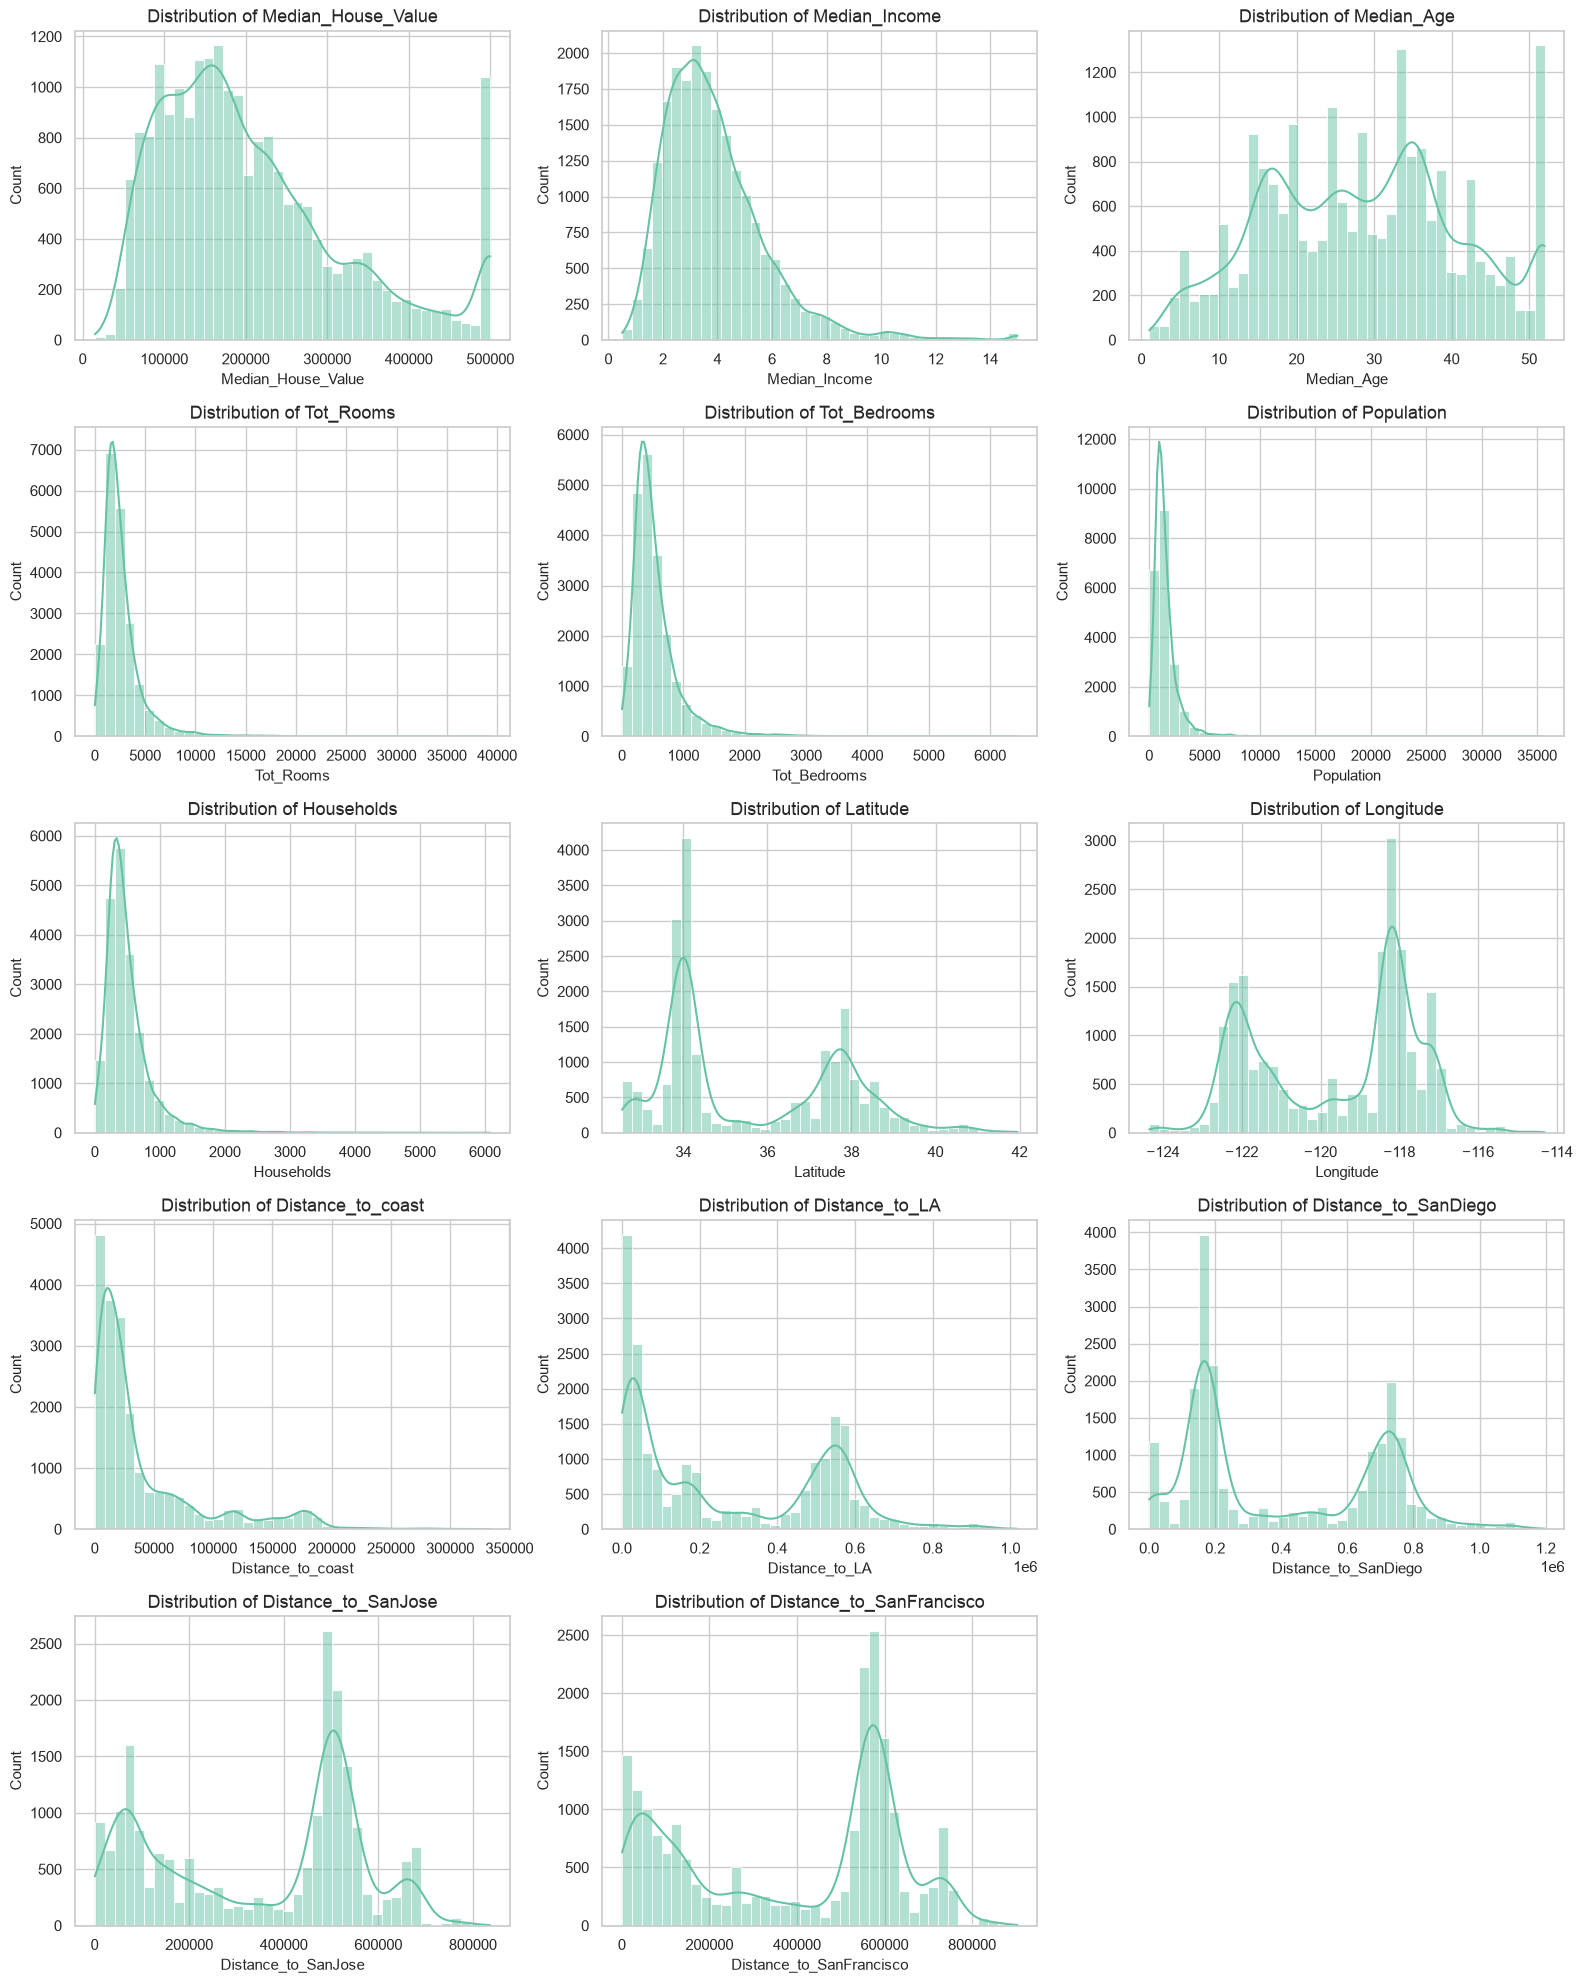

In [21]:
n_cols = 3
n_rows = int(np.ceil(len(numerical_features) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for ax, feature in zip(axes, numerical_features):
    sns.histplot(df[feature], kde=True, bins=40, ax=ax)
    ax.set_title(f"Distribution of {feature}")
    ax.set_xlabel(feature)

for ax in axes[len(numerical_features):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

#### Numerical Features: Outlier Detection

Sử dụng quy tắc IQR để đếm số lượng outlier của từng biến số. Boxplot giúp quan sát trực quan các giá trị nằm ngoài khoảng thông thường.

In [8]:
outlier_rows = []

for feature in numerical_features:
    q1 = df[feature].quantile(0.25)
    q3 = df[feature].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outlier_mask = (df[feature] < lower_bound) | (df[feature] > upper_bound)
    outlier_rows.append({
        "feature": feature,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": int(outlier_mask.sum()),
        "outlier_ratio": float(outlier_mask.mean()),
    })

outlier_summary = pd.DataFrame(outlier_rows).sort_values("outlier_ratio", ascending=False)
outlier_summary

,feature,lower_bound,upper_bound,outlier_count,outlier_ratio
9,Distance_to_coast,-52046.229811,1.109564e+05,2376,0.115116
3,Tot_Rooms,-1102.625000,5.698375e+03,1287,0.062355
4,Tot_Bedrooms,-233.000000,1.175000e+03,1282,0.062112
6,Households,-207.500000,1.092500e+03,1220,0.059109
5,Population,-620.000000,3.132000e+03,1196,0.057946
0,Median_House_Value,-98087.500000,4.824125e+05,1071,0.051890
1,Median_Income,-0.706375,8.013025e+00,681,0.032994
2,Median_Age,-10.500000,6.550000e+01,0,0.000000
7,Latitude,28.260000,4.338000e+01,0,0.000000
8,Longitude,-127.485000,-1.123250e+02,0,0.000000


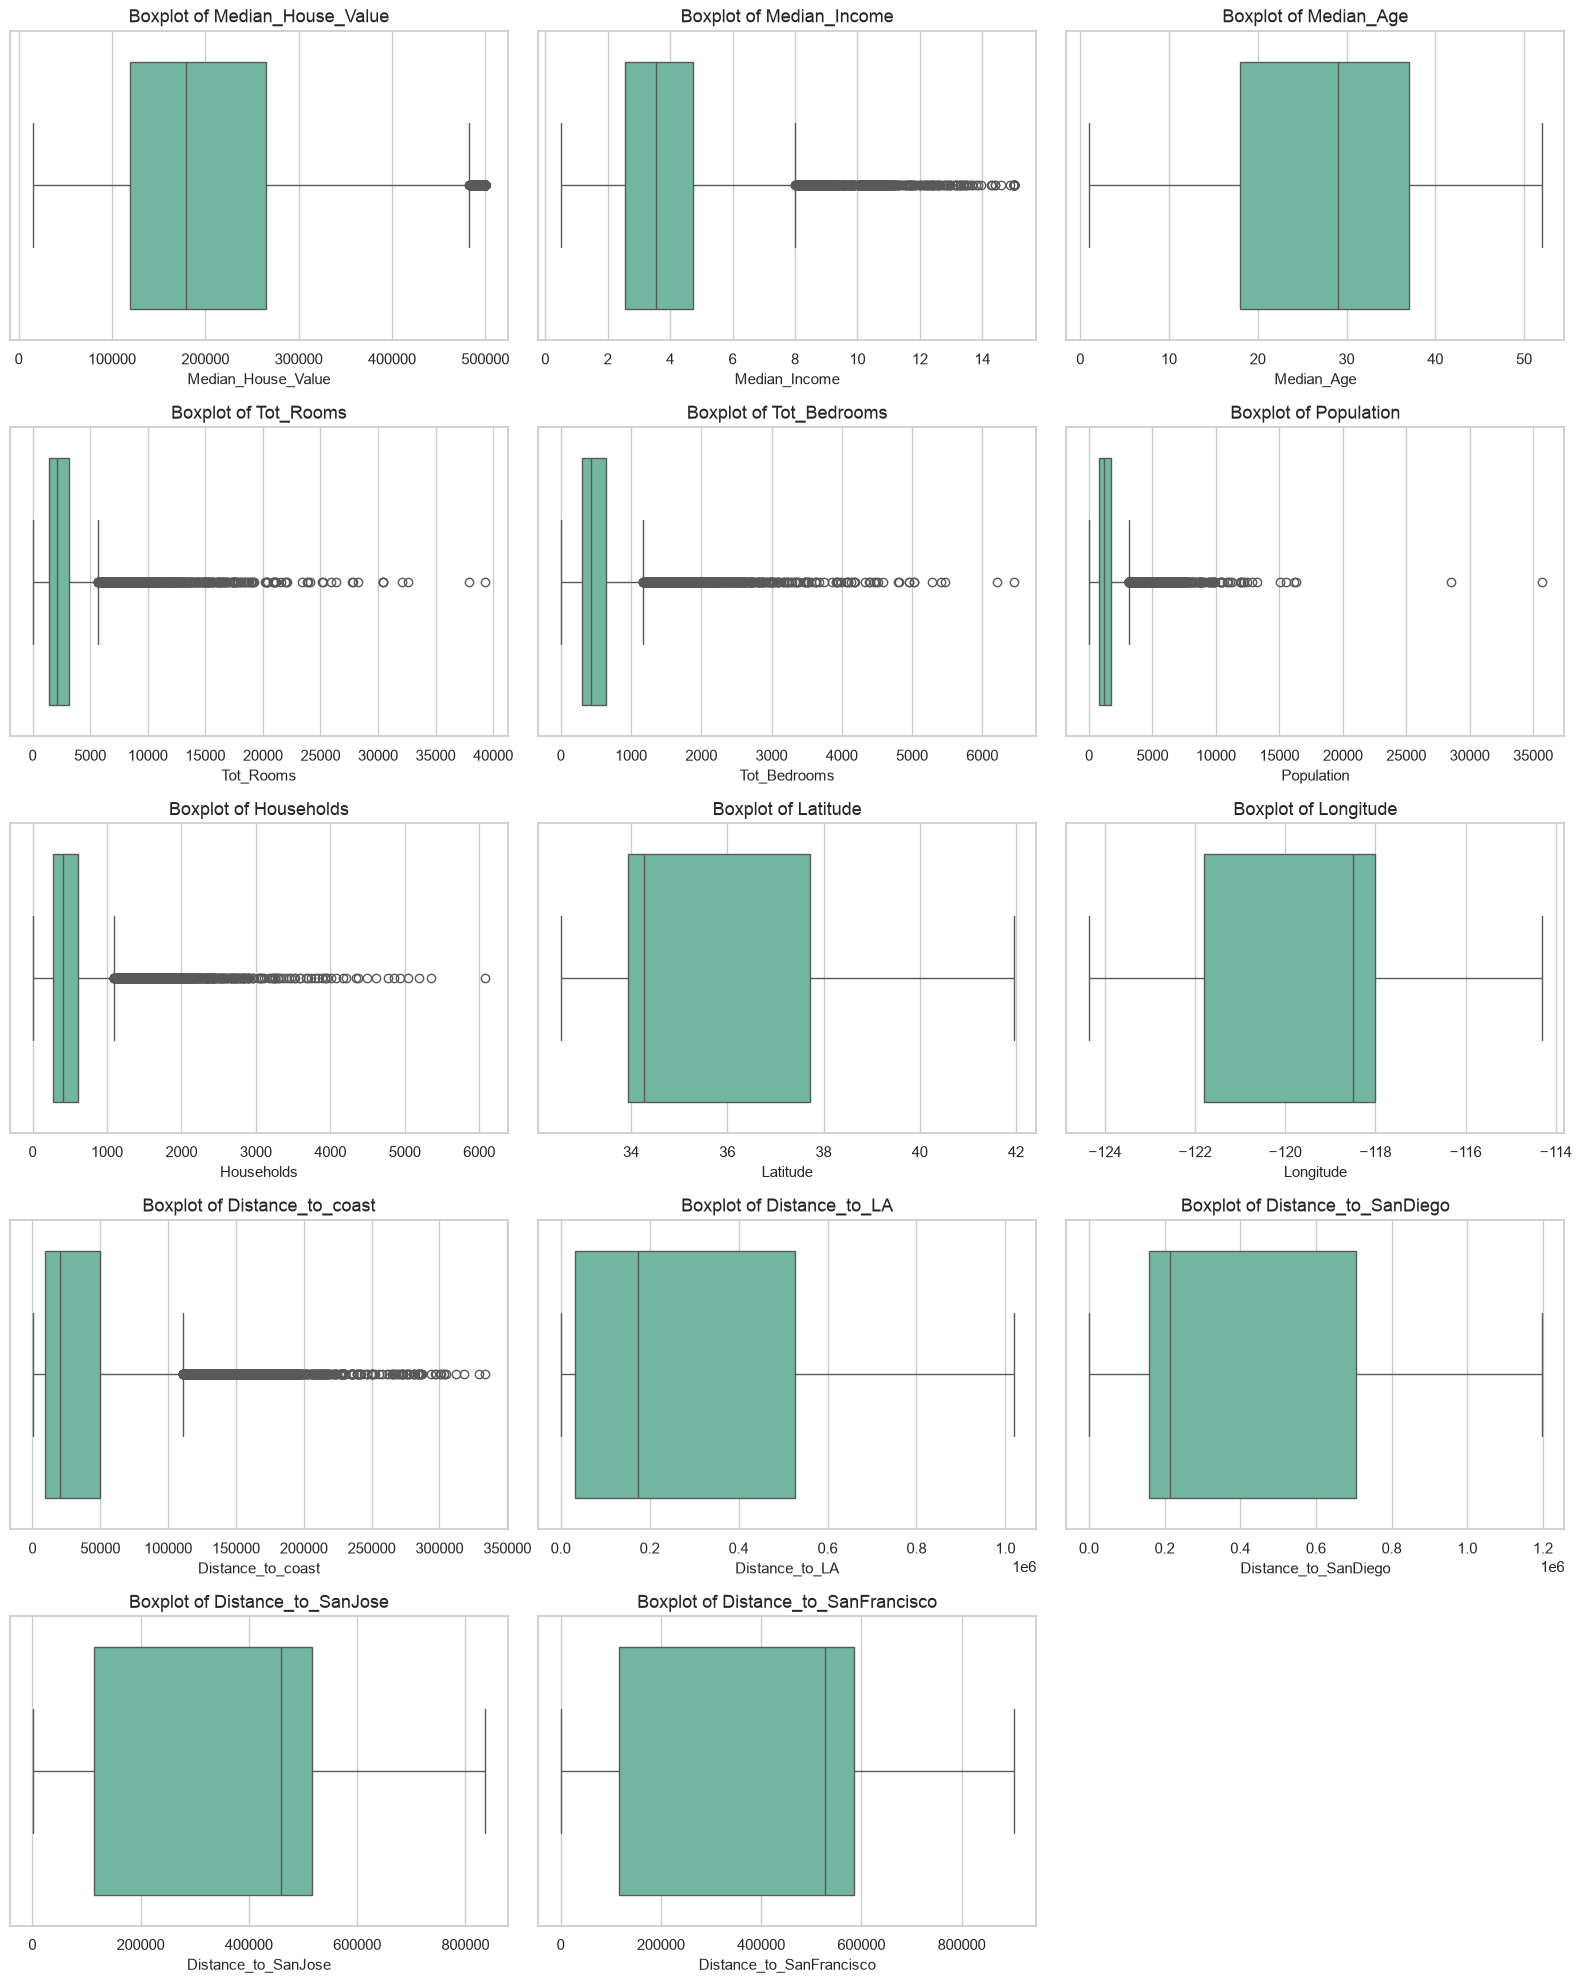

In [9]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for ax, feature in zip(axes, numerical_features):
    sns.boxplot(x=df[feature], ax=ax)
    ax.set_title(f"Boxplot of {feature}")
    ax.set_xlabel(feature)

for ax in axes[len(numerical_features):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

#### Categorical Features: Bar Plots


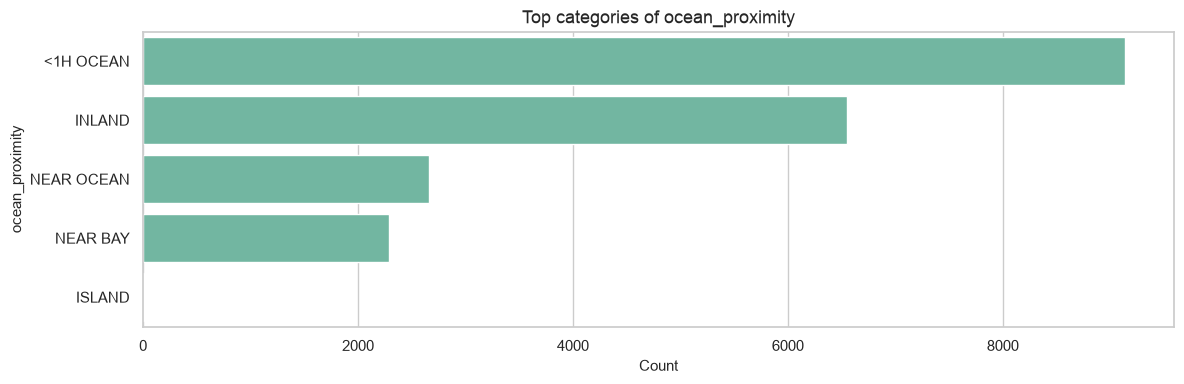

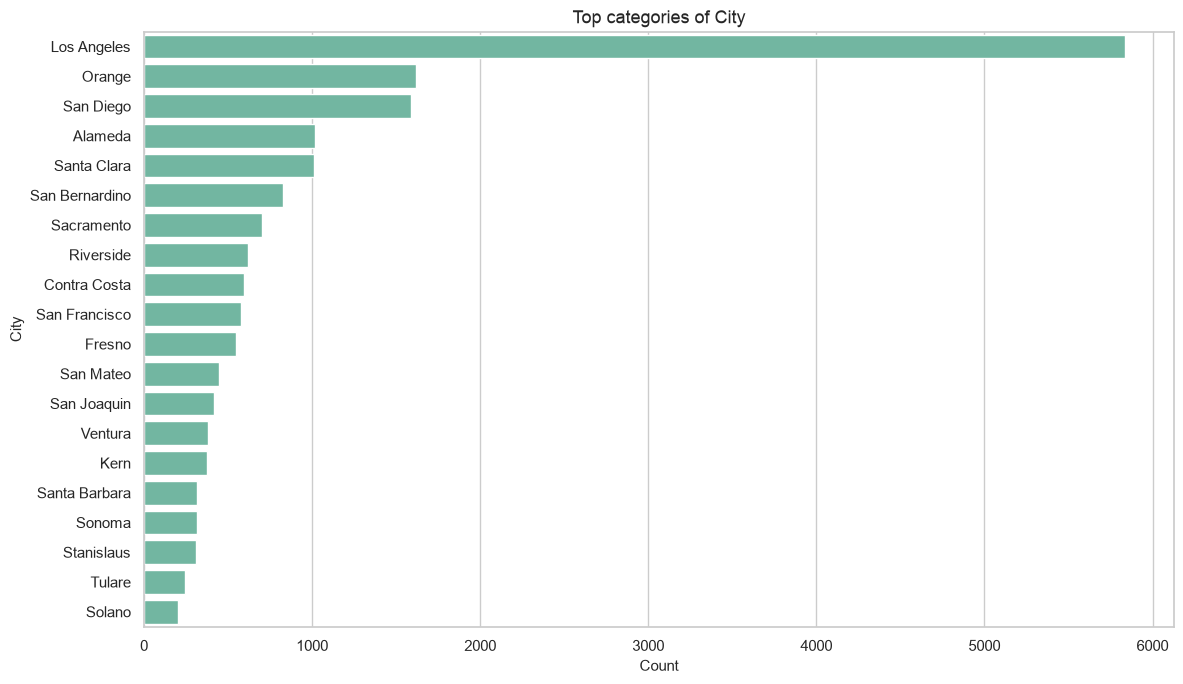

In [22]:
for feature in categorical_features:
    top_counts = df[feature].value_counts(dropna=False).head(20)
    plt.figure(figsize=(12, max(4, 0.35 * len(top_counts))))
    sns.barplot(x=top_counts.values, y=top_counts.index.astype(str), orient="h")
    plt.title(f"Top categories of {feature}")
    plt.xlabel("Count")
    plt.ylabel(feature)
    plt.tight_layout()
    plt.show()

### Multivariable Analysis

#### Numerical vs Numerical: Correlation Heatmap

Correlation heatmap giúp quan sát quan hệ tuyến tính giữa các biến số, đặc biệt là quan hệ giữa từng feature và `Median_House_Value`.

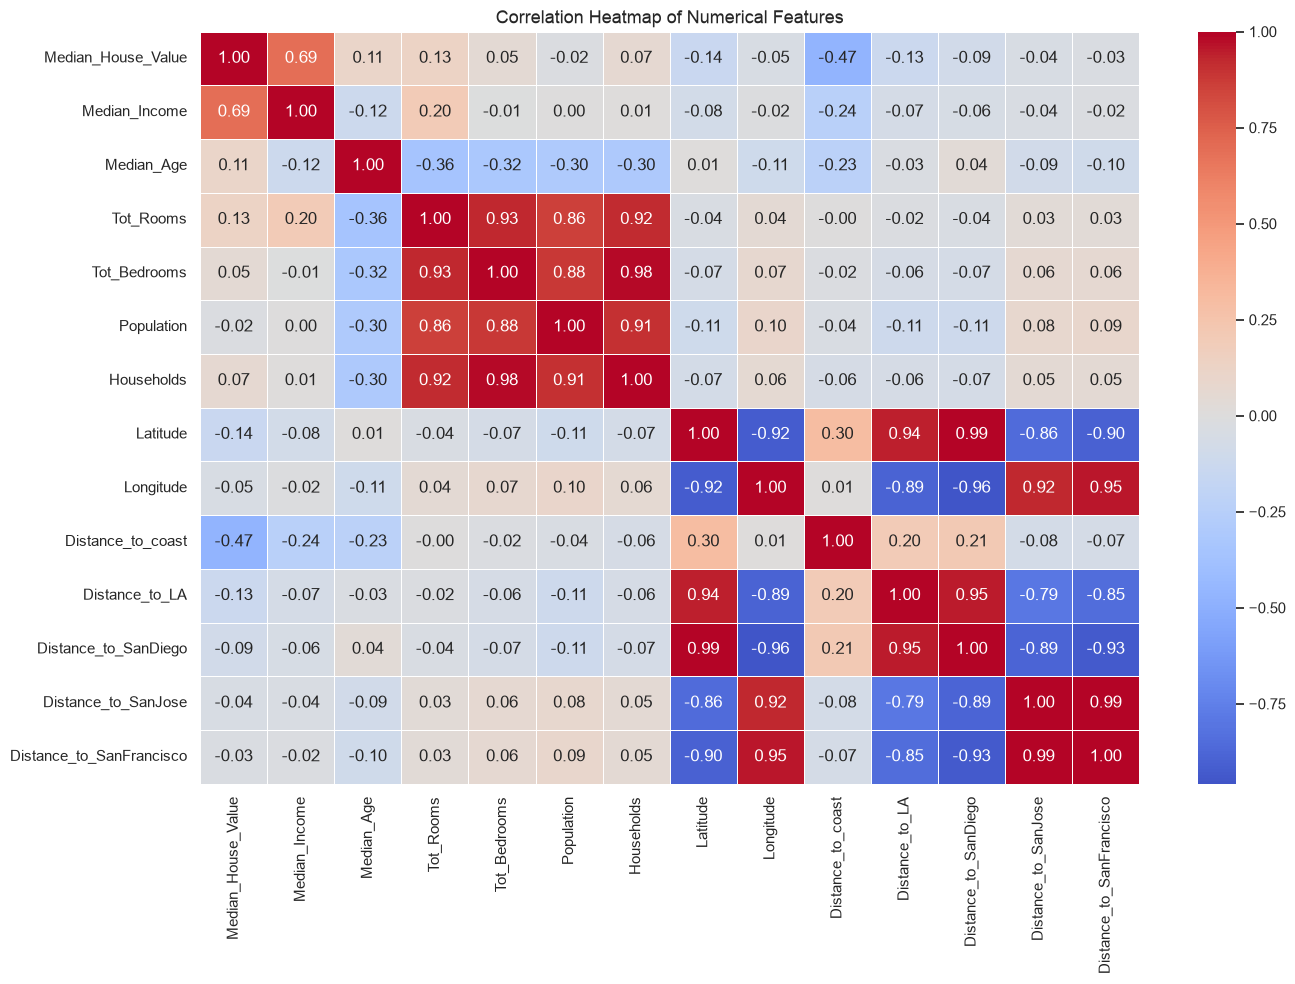

Median_House_Value          1.000000
Median_Income               0.688075
Tot_Rooms                   0.134153
Median_Age                  0.105623
Households                  0.065843
Tot_Bedrooms                0.050594
Population                 -0.024650
Distance_to_SanFrancisco   -0.030559
Distance_to_SanJose        -0.041590
Longitude                  -0.045967
Distance_to_SanDiego       -0.092510
Distance_to_LA             -0.130678
Latitude                   -0.144160
Distance_to_coast          -0.469350
Name: Median_House_Value, dtype: float64

In [11]:
corr = df[numerical_features].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

corr[TARGET].sort_values(ascending=False)

#### Numerical vs Target: Selected Scatter Plots

Các scatter plot bên dưới tập trung vào những biến có ý nghĩa trực quan hoặc có khả năng liên quan mạnh đến giá nhà.

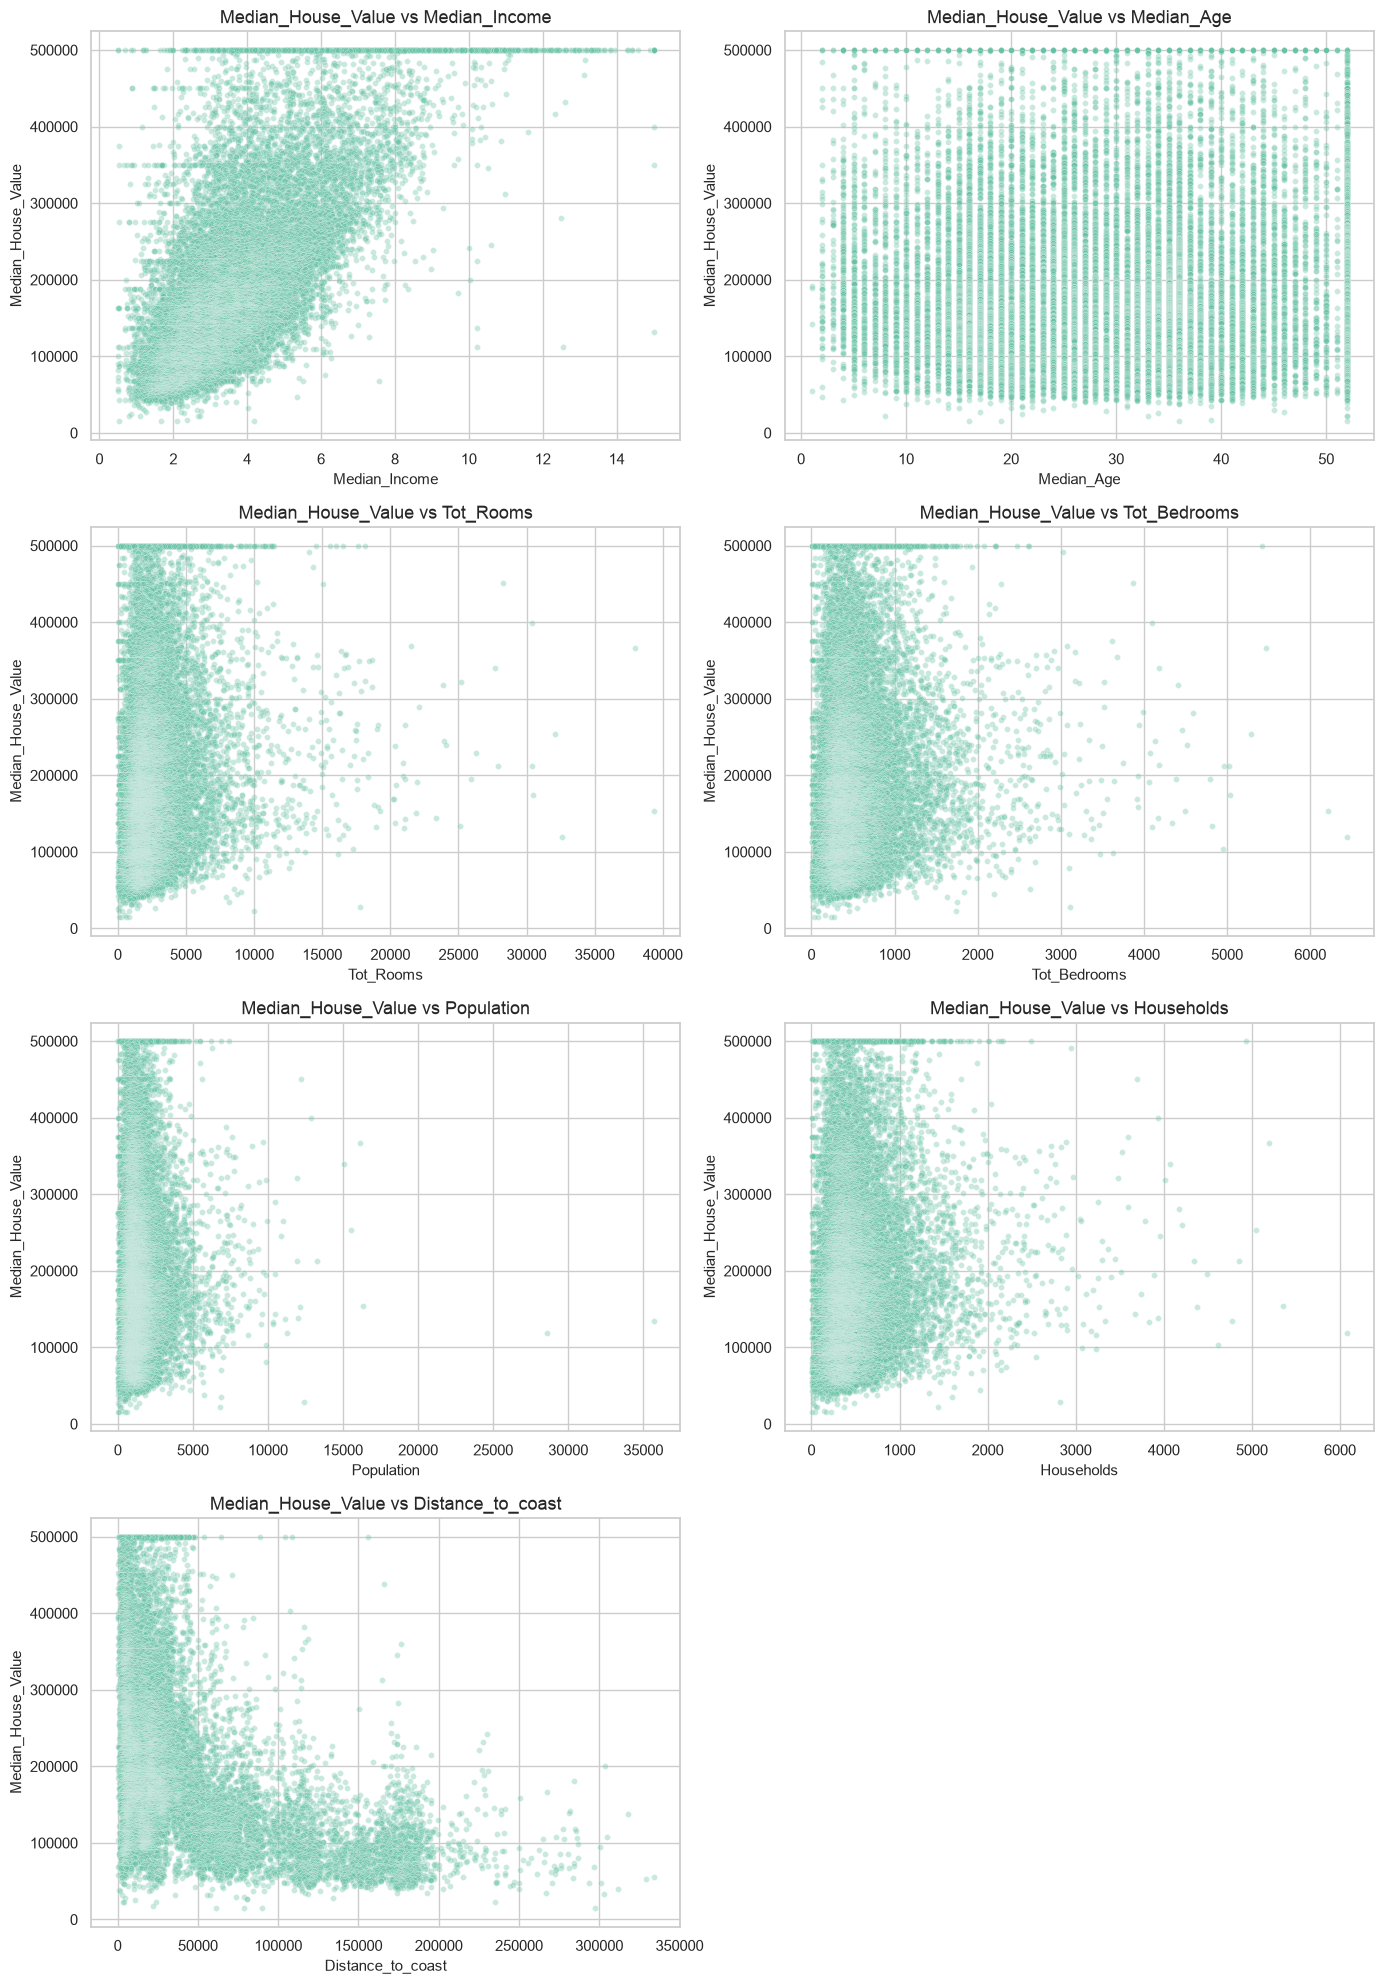

In [41]:
selected_numeric_features = [
    "Median_Income",
    "Median_Age",
    "Tot_Rooms",
    "Tot_Bedrooms",
    "Population",
    "Households",
    "Distance_to_coast",
]
selected_numeric_features = [feature for feature in selected_numeric_features if feature in df.columns]

n_cols = 2
n_rows = int(np.ceil(len(selected_numeric_features) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
axes = np.array(axes).flatten()

for ax, feature in zip(axes, selected_numeric_features):
    sns.scatterplot(data=df, x=feature, y=TARGET, alpha=0.35, s=18, ax=ax)
    ax.set_title(f"{TARGET} vs {feature}")

for ax in axes[len(selected_numeric_features):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

#### Categorical vs Numerical: Target Distribution by Category

So sánh phân phối `Median_House_Value` giữa các nhóm phân loại. Với `City`, chỉ dùng các thành phố xuất hiện nhiều nhất để tránh biểu đồ quá dày.

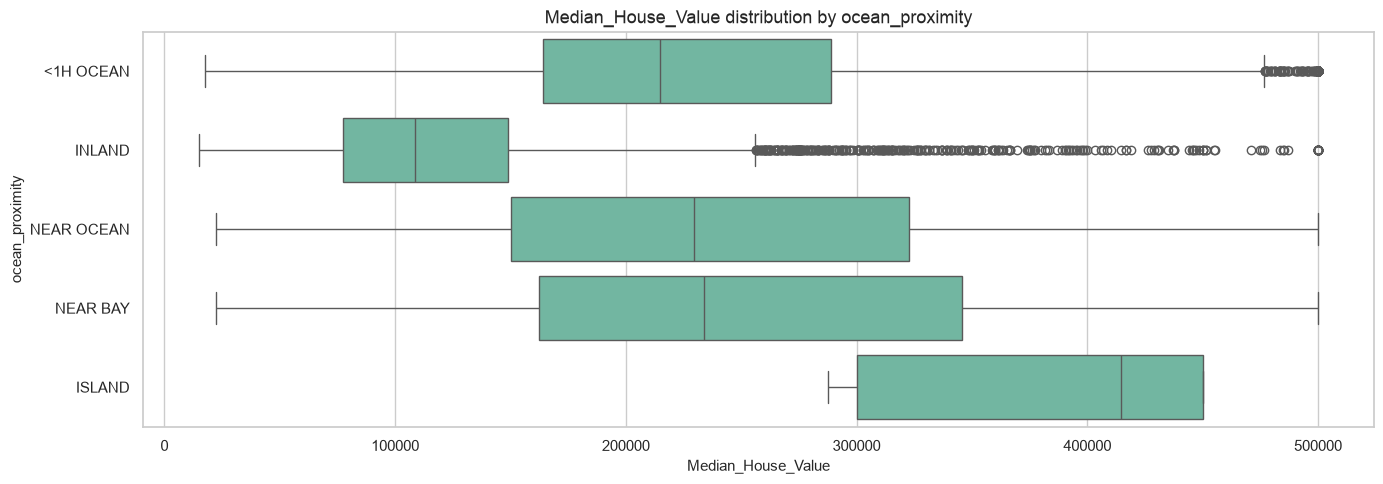

,count,mean,median,std
ocean_proximity,,,,
ISLAND,5,380440.000000,414700.0,80559.561816
NEAR BAY,2290,259212.311790,233800.0,122818.537064
NEAR OCEAN,2658,249433.977427,229450.0,122477.145927
<1H OCEAN,9136,240084.285464,214850.0,106124.292213
INLAND,6551,124805.392001,108500.0,70007.908494


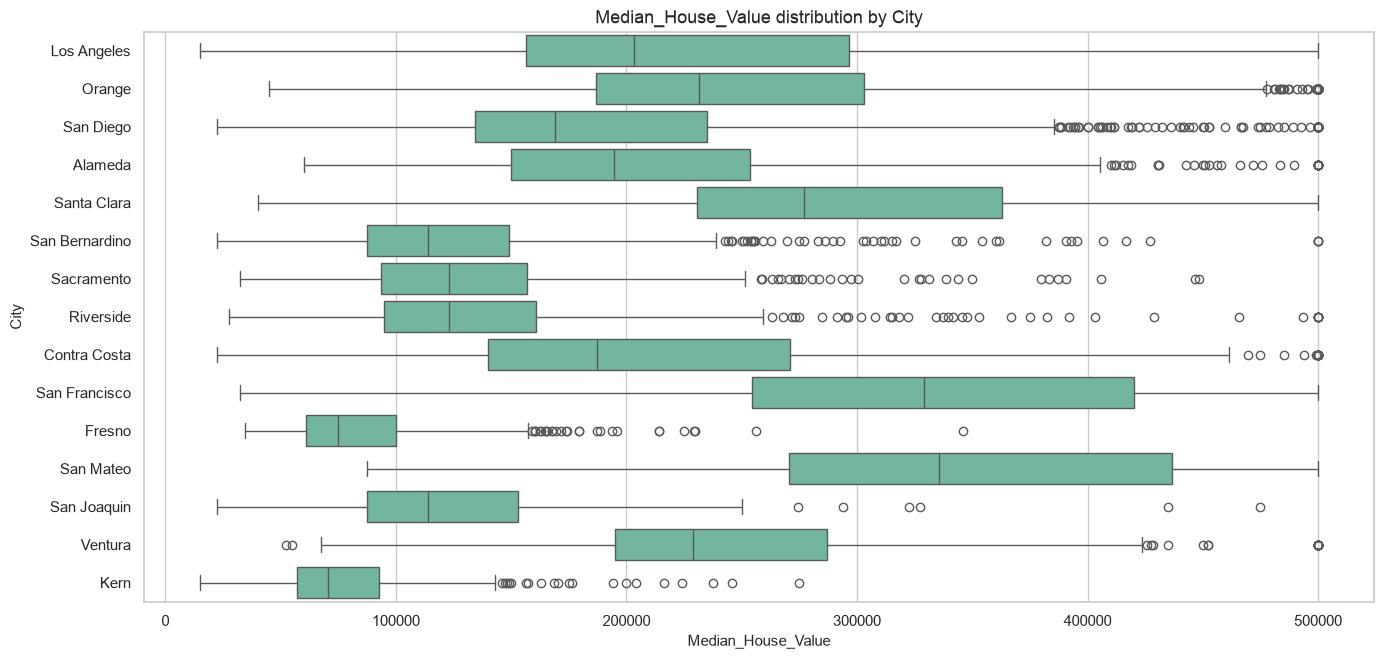

,count,mean,median,std
City,,,,
San Mateo,448,348789.245536,335500.0,101671.998339
San Francisco,574,338793.712544,329150.0,104815.097445
Santa Clara,1011,302378.846686,276900.0,103728.142255
Orange,1620,257896.728395,231400.0,100315.709490
Ventura,378,252320.674603,229000.0,86572.406479
Los Angeles,5836,238652.523132,203450.0,114692.490280
Alameda,1018,209406.888016,194650.0,88388.503983
Contra Costa,593,216243.701518,187100.0,104776.613173
San Diego,1590,196839.146541,169150.0,95194.382296


In [42]:
for feature in categorical_features:
    top_categories = df[feature].value_counts().head(15).index
    plot_df = df[df[feature].isin(top_categories)].copy()

    plt.figure(figsize=(14, max(5, 0.45 * len(top_categories))))
    sns.boxplot(data=plot_df, y=feature, x=TARGET, order=top_categories)
    plt.title(f"{TARGET} distribution by {feature}")
    plt.xlabel(TARGET)
    plt.ylabel(feature)
    plt.tight_layout()
    plt.show()

    display(
        plot_df.groupby(feature)[TARGET]
        .agg(["count", "mean", "median", "std"])
        .sort_values("median", ascending=False)
    )

#### Categorical vs Categorical: Crosstab Heatmap

Nếu có ít nhất hai biến phân loại, sử dụng crosstab để xem mối quan hệ tần suất giữa các nhóm. Với các biến có nhiều giá trị, chỉ lấy nhóm phổ biến nhất.

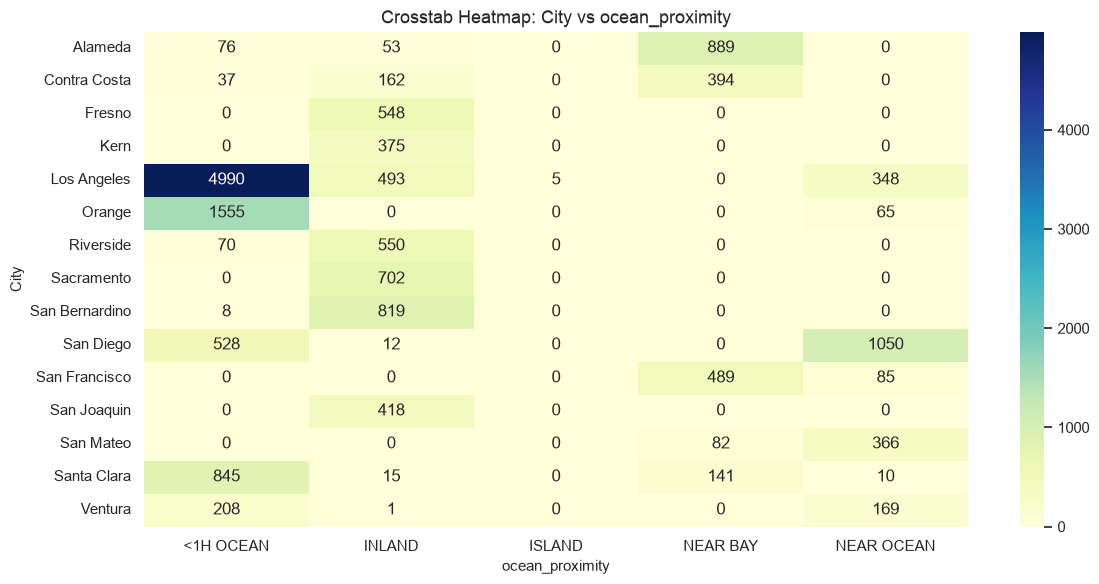

In [14]:
if len(categorical_features) >= 2:
    cat_a, cat_b = categorical_features[:2]
    top_a = df[cat_a].value_counts().head(10).index
    top_b = df[cat_b].value_counts().head(15).index
    cat_df = df[df[cat_a].isin(top_a) & df[cat_b].isin(top_b)]

    crosstab = pd.crosstab(cat_df[cat_b], cat_df[cat_a])
    plt.figure(figsize=(12, max(5, 0.4 * len(crosstab))))
    sns.heatmap(crosstab, annot=True, fmt="d", cmap="YlGnBu")
    plt.title(f"Crosstab Heatmap: {cat_b} vs {cat_a}")
    plt.xlabel(cat_a)
    plt.ylabel(cat_b)
    plt.tight_layout()
    plt.show()
else:
    print("Dataset có ít hơn 2 biến phân loại, không đủ để phân tích categorical vs categorical.")

#### Spatial Analysis: California Map-style Scatter Plot

Biểu đồ scatter theo `Longitude` và `Latitude` cho thấy phân bố không gian của giá nhà. Màu sắc biểu diễn `Median_House_Value`, giúp quan sát khu vực nào có giá trị nhà cao hoặc thấp hơn.

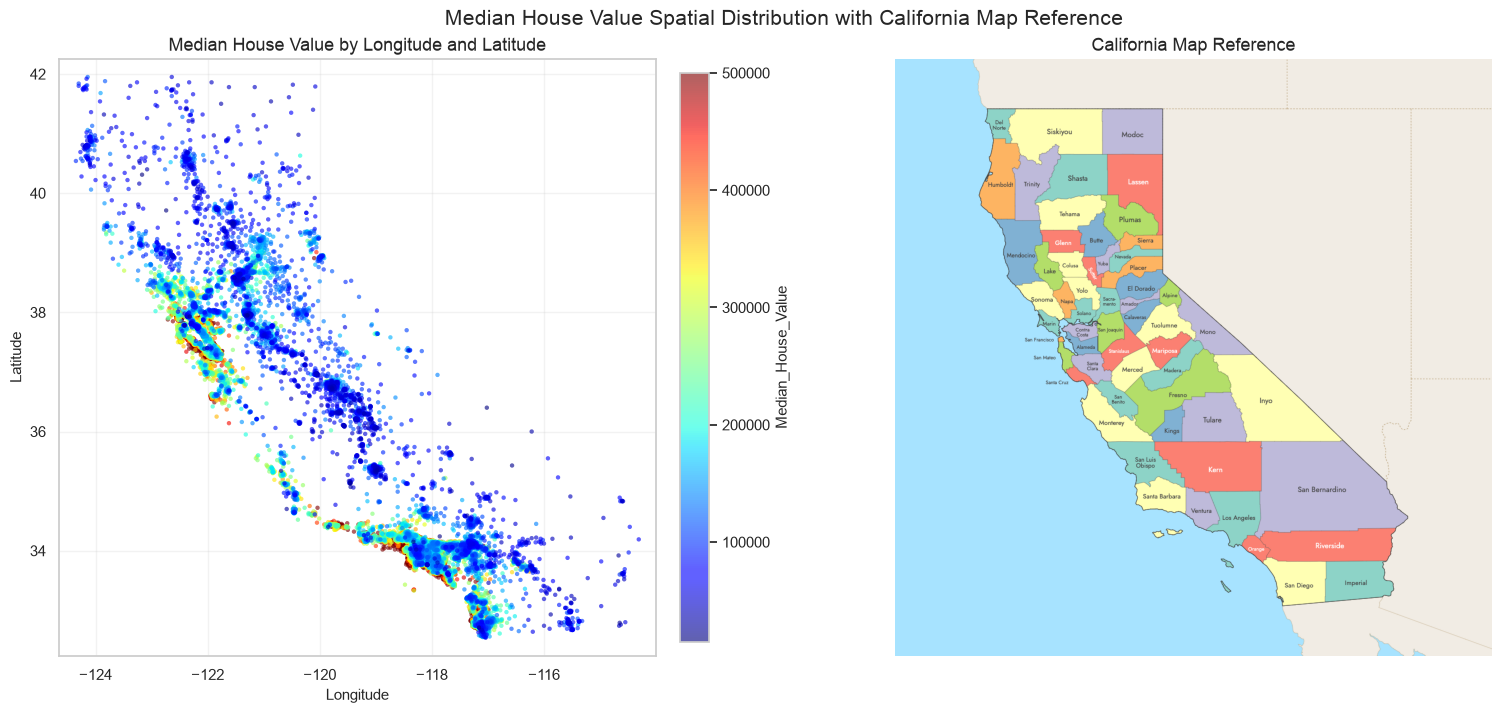

In [43]:
import matplotlib.image as mpimg

map_candidates = sorted(Path("assets").glob("*.jpg")) + sorted(Path("practice_4/assets").glob("*.jpg"))
if not map_candidates:
    raise FileNotFoundError("Không tìm thấy ảnh California map trong thư mục assets/*.jpg")

california_map_path = map_candidates[0]
california_map = mpimg.imread(california_map_path)

lon_padding = 0.3
lat_padding = 0.3
plot_extent = [
    df["Longitude"].min() - lon_padding,
    df["Longitude"].max() + lon_padding,
    df["Latitude"].min() - lat_padding,
    df["Latitude"].max() + lat_padding,
]

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 7),
    constrained_layout=True,
    gridspec_kw={"width_ratios": [1, 1.25]},
)

scatter = axes[0].scatter(
    df["Longitude"],
    df["Latitude"],
    c=df[TARGET],
    cmap="jet",
    alpha=0.62,
    s=10,
    edgecolors="none",
)
axes[0].set_title("Median House Value by Longitude and Latitude")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
axes[0].set_xlim(plot_extent[0], plot_extent[1])
axes[0].set_ylim(plot_extent[2], plot_extent[3])
axes[0].set_box_aspect(1)
axes[0].grid(alpha=0.25)
plt.colorbar(scatter, ax=axes[0], label=TARGET, fraction=0.046, pad=0.04)

axes[1].imshow(california_map)
axes[1].set_title("California Map Reference")
axes[1].set_box_aspect(1)
axes[1].axis("off")

fig.suptitle("Median House Value Spatial Distribution with California Map Reference", fontsize=15)
plt.show()

# Data Preprocessing

# Feature Engineering